# EDA — Dataset EDOS (Sexism Detection)

### 1. Carga y estructura del dataset

In [ ]:

import polars as pl
import altair as alt
import pyarrow as pa
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

alt.data_transformers.enable("vegafusion")
plt.style.use("seaborn-v0_8-whitegrid")

df = pl.read_parquet(Path(__file__).resolve().parent.parent / "data" / "processed" / "merged_edos_sexism.parquet")
df_pd = df.to_pandas()



NameError: name '__file__' is not defined

### 2.Nulos 

In [15]:
df.isnull().sum()

rewire_id         0
text              0
label_sexist      0
label_category    0
label_vector      0
split             0
dtype: int64

### 3. Duplicados

In [16]:
df.duplicated().sum()

np.int64(0)

### 4. Análisis univariado — label_sexist

Contamos cuántos textos hay de cada clase (sexist / not sexist)
para ver la distribución general antes de cruzar con otras columnas.

In [19]:
df['label_sexist'].value_counts()

label_sexist
not sexist    15146
sexist         4854
Name: count, dtype: int64

#### Visualización — distribución de label_sexist

Gráfico de torta para mostrar la proporción de cada clase.
Se confirma el desbalance: ~76% not sexist vs ~24% sexist.

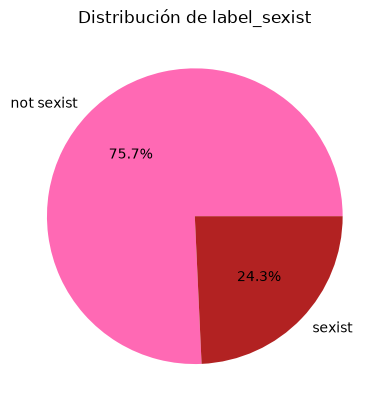

In [20]:
import matplotlib.pyplot as plt

conteo = df['label_sexist'].value_counts()

plt.pie(conteo, labels=conteo.index, autopct='%1.1f%%', colors=['#FF69B4', '#B22222'])
plt.title('Distribución de label_sexist')
plt.show()

### 5. Análisis univariado — label_category (solo textos sexistas)

Esta columna solo tiene valor real cuando `label_sexist = "sexist"`.
En el resto de las filas aparece como "none", así que filtramos
primero para no diluir el análisis con ese valor dominante.

In [22]:
sexistas = df[df['label_sexist'] == 'sexist']
sexistas['label_category'].value_counts()

label_category
2. derogation                               2271
3. animosity                                1665
4. prejudiced discussions                    475
1. threats, plans to harm and incitement     443
Name: count, dtype: int64

In [24]:
df.sample(5)

,rewire_id,text,label_sexist,label_category,label_vector,split
18742,sexism2022_english-934,I wish everyone would stop calling the left sn...,not sexist,none,none,train
12125,sexism2022_english-2669,"fuck your options, women shouldn't rights and ...",sexist,4. prejudiced discussions,4.2 supporting systemic discrimination against...,train
847,sexism2022_english-5803,I don't even care about them mocking his baldi...,not sexist,none,none,train
18999,sexism2022_english-200,[USER] She'll cancel out soon enough. I never ...,not sexist,none,none,train
13946,sexism2022_english-15760,J thought Danton was fo shizzle and banged bla...,not sexist,none,none,train
